In [2]:
#importing libraries
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv('Iris.csv')

In [4]:
x_data_sepal_length = np.array([x for x in np.array(df['SepalLengthCm'])])
x_data_sepal_width = np.array([x for x in np.array(df['SepalWidthCm'])])
x_data_petal_length = np.array([x for x in np.array(df['PetalLengthCm'])])
x_data_petal_width = np.array([x for x in np.array(df['PetalWidthCm'])])
x_data = np.column_stack((x_data_sepal_length,x_data_sepal_width,x_data_petal_length,x_data_petal_width))

In [5]:
print(x_data)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [6]:
y_data = np.array(df['Species'])
print(y_data)

[tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<U11', requires_grad=True)
 tensor('Iris-setosa', dtype='<

In [7]:
y_data = np.array([0 if x=='Iris-setosa' else 1 if x=='Iris-versicolor' else 2 for x in y_data])
print(y_data)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x_data,y_data)

In [10]:
x_train

tensor([[6.2, 3.4, 5.4, 2.3],
        [6.2, 2.9, 4.3, 1.3],
        [6.7, 3.3, 5.7, 2.5],
        [6.7, 3.1, 4.4, 1.4],
        [5. , 3.5, 1.3, 0.3],
        [5.6, 2.5, 3.9, 1.1],
        [5.5, 3.5, 1.3, 0.2],
        [5.1, 3.5, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.7, 4.4, 1.5, 0.4],
        [6.1, 2.8, 4. , 1.3],
        [5. , 3.6, 1.4, 0.2],
        [5.9, 3. , 5.1, 1.8],
        [6.7, 3. , 5. , 1.7],
        [5.5, 2.3, 4. , 1.3],
        [7. , 3.2, 4.7, 1.4],
        [5.8, 4. , 1.2, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [6.1, 2.8, 4.7, 1.2],
        [5.4, 3.9, 1.7, 0.4],
        [6.4, 2.7, 5.3, 1.9],
        [7.2, 3.2, 6. , 1.8],
        [6.1, 3. , 4.6, 1.4],
        [5. , 3.4, 1.5, 0.2],
        [5. , 3.5, 1.6, 0.6],
        [4.7, 3.2, 1.6, 0.2],
        [6.3, 3.4, 5.6, 2.4],
        [6.3, 2.9, 5.6, 1.8],
        [5.5, 2.6, 4.4, 1.2],
        [5.7, 2.9, 4.2, 1.3],
        [5.4, 3.4, 1.5, 0.4],
        [5. , 3. , 1.6, 0.2],
        [7.6, 3. , 6.6, 2.1],
        [5

In [11]:
y_train

tensor([2, 1, 2, 1, 0, 1, 0, 0, 0, 0, 1, 0, 2, 1, 1, 1, 0, 0, 1, 0, 2, 2,
        1, 0, 0, 0, 2, 2, 1, 1, 0, 0, 2, 1, 2, 0, 2, 1, 1, 0, 0, 1, 1, 0,
        2, 2, 1, 1, 1, 0, 2, 0, 2, 1, 0, 2, 2, 1, 2, 0, 1, 2, 1, 1, 2, 0,
        2, 0, 1, 1, 0, 2, 2, 1, 0, 0, 0, 1, 0, 2, 0, 0, 2, 2, 0, 1, 1, 1,
        1, 1, 2, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 2, 0, 2, 1, 0, 1, 1, 0, 2,
        0, 0], requires_grad=True)

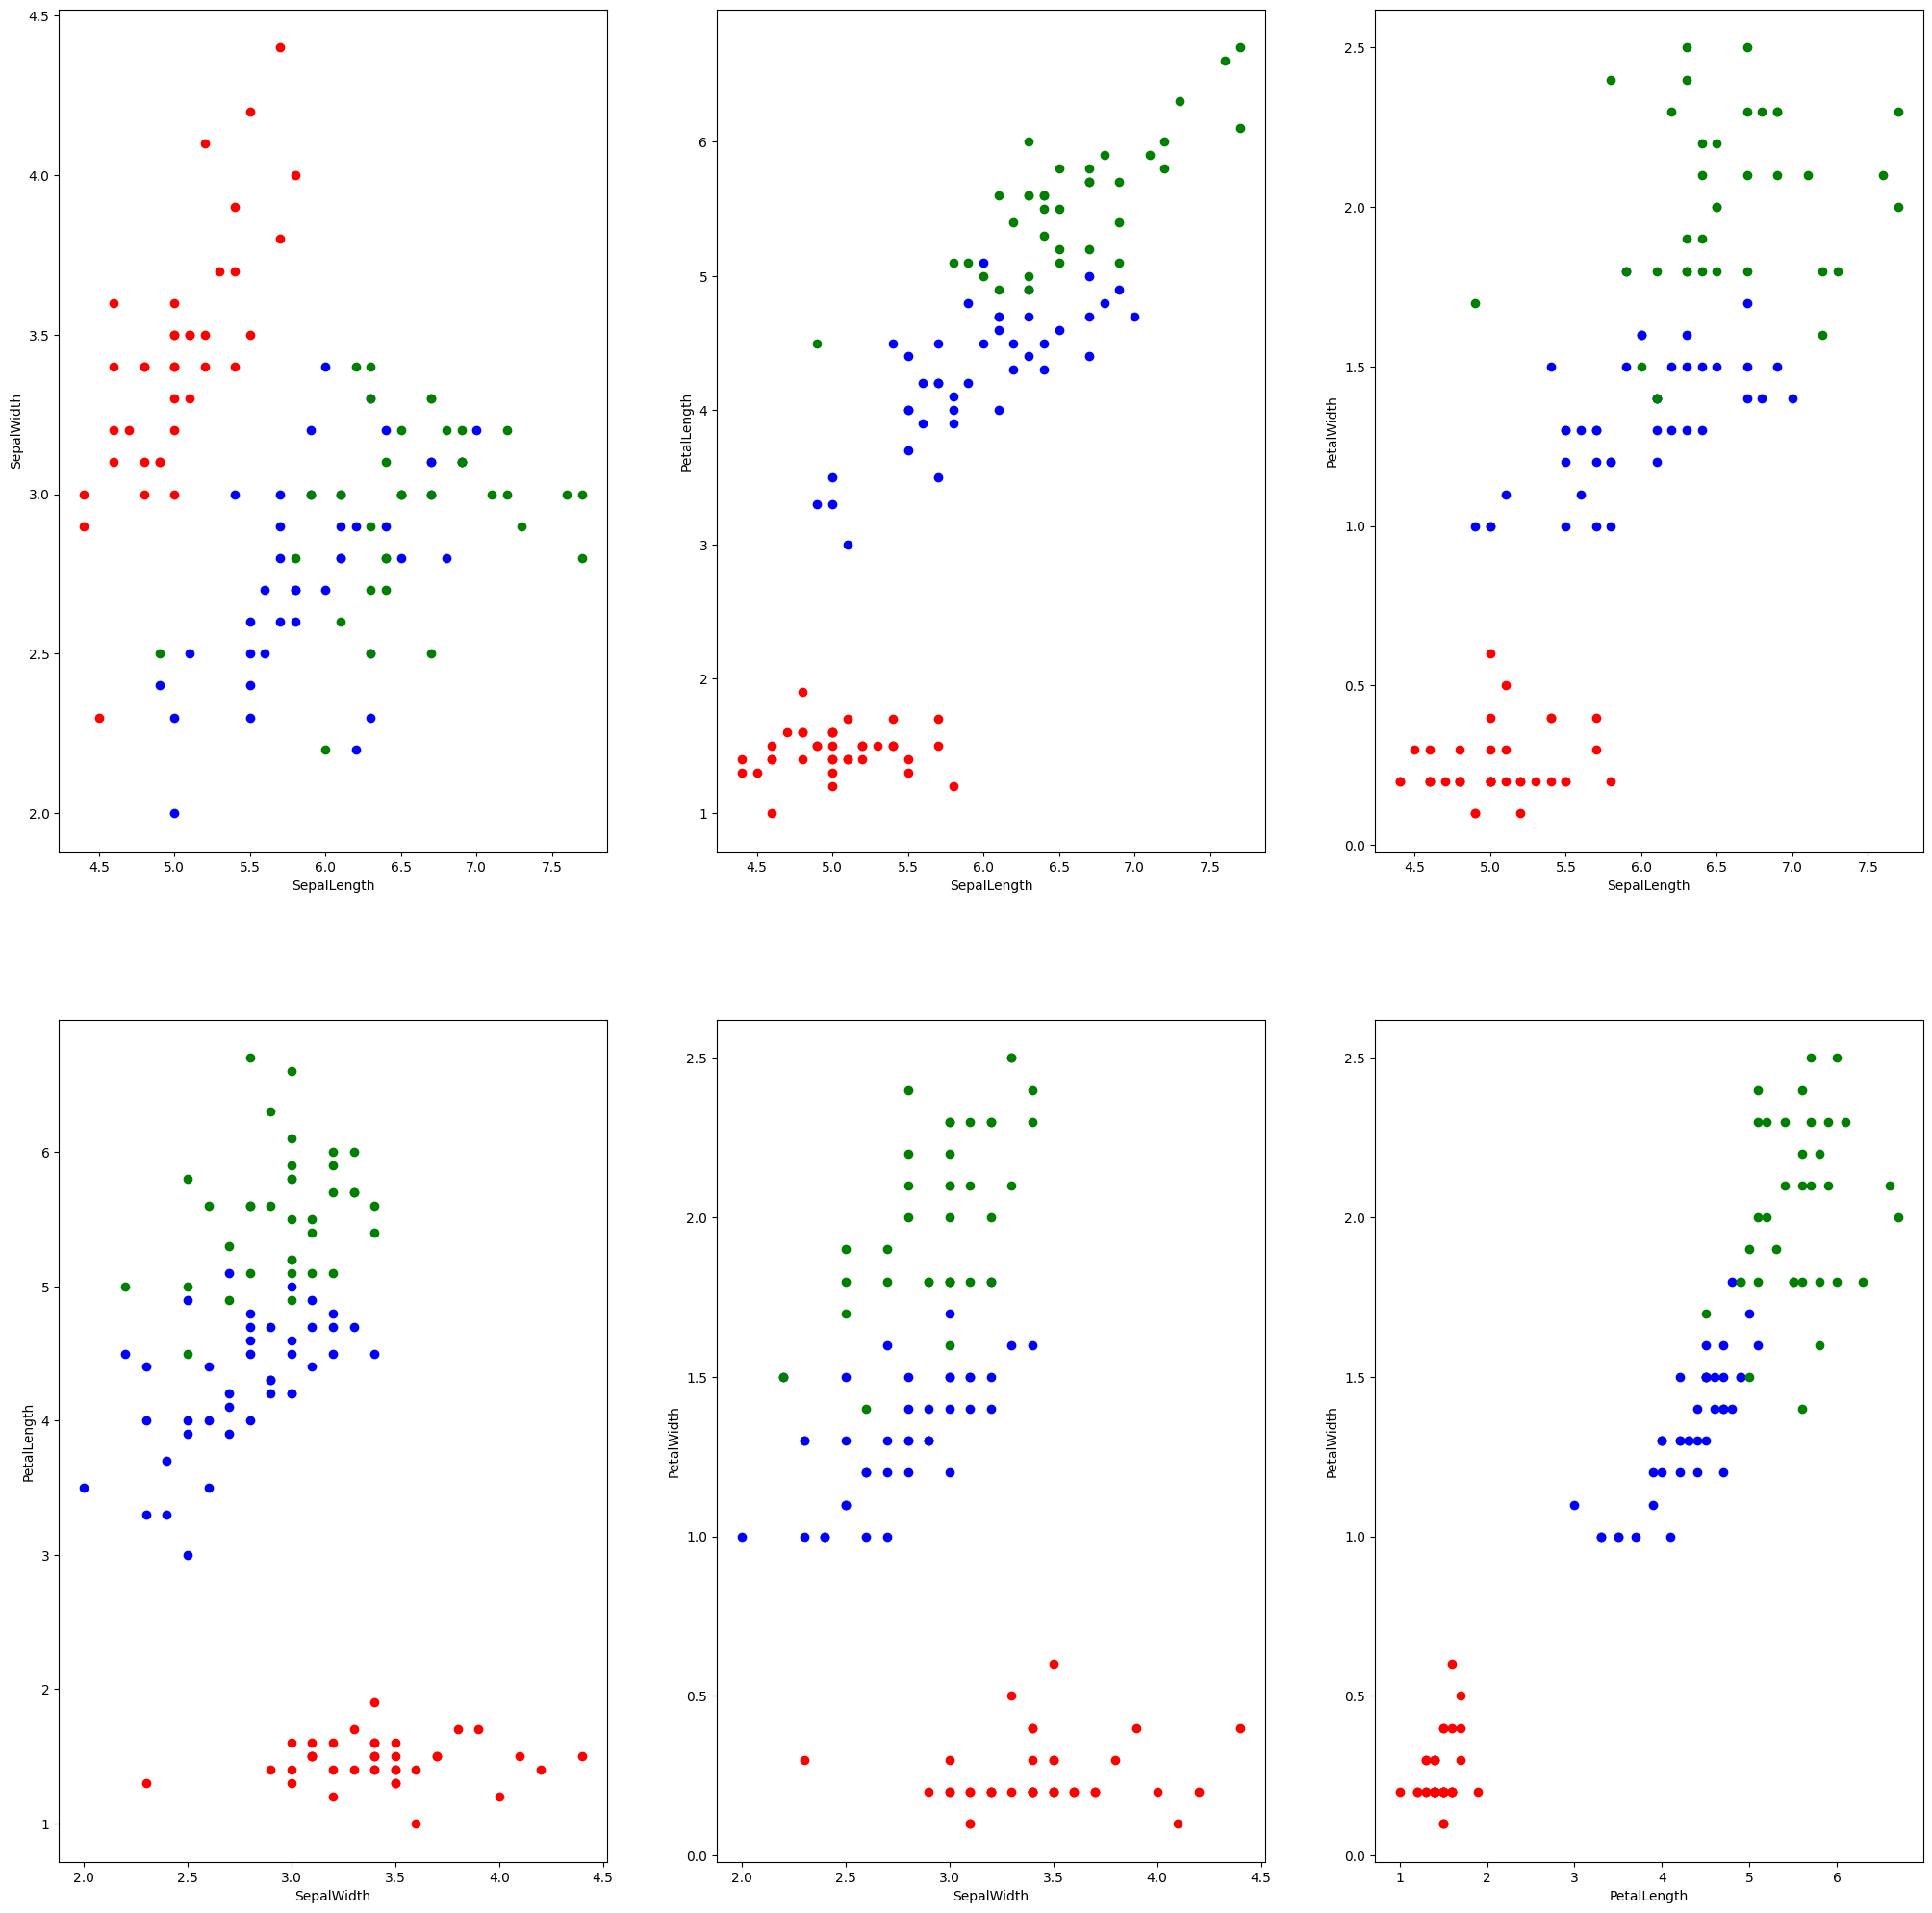

In [12]:
def title(i):
    if i==0:
        return "SepalLength"
    elif i==1:
        return "SepalWidth"
    elif i==2:
        return "PetalLength"
    return "PetalWidth"
fig,ax = plt.subplots(2,3,figsize=(25,25))
x_train_0 = x_train[y_train==0]
x_train_1 = x_train[y_train==1]
x_train_2 = x_train[y_train==2]
index = 0
idx=0
for i in range(4):
    for j in range(i+1,4):
        ax[index][idx].scatter(x_train_0[:,i],x_train_0[:,j],color='r')
        ax[index][idx].scatter(x_train_1[:,i],x_train_1[:,j],color='b')
        ax[index][idx].scatter(x_train_2[:,i],x_train_2[:,j],color='g')
        ax[index][idx].set_xlabel(title(i))
        ax[index][idx].set_ylabel(title(j))
        idx=(idx+1)%3
        if idx==0:
            index+=1

In [13]:
dev = qml.device('default.qubit',wires=5)

In [14]:
def quantum_function(a,b):
    a_normalize = a/np.linalg.norm(a)
    b_normalize = b/np.linalg.norm(b)
    qml.AmplitudeEmbedding(features=np.concatenate((a,b)),wires=[1,2,3],normalize=True)
    qml.AmplitudeEmbedding(features=np.array([np.linalg.norm(a),-np.linalg.norm(b)]),wires=4,normalize=True)
    qml.Hadamard(wires=0)
    qml.CSWAP(wires=[0,1,4])
    qml.Hadamard(wires=0)
    return qml.probs(wires=0)

In [15]:
circuit = qml.QNode(quantum_function,dev)

In [16]:
def KNN(k,x_train,x_test,y_train,y_test):
    y_pred=np.array([x for x in y_test])
    for i in range(len(x_test)):
        test = x_test[i]
        distances = []
        for j in range(len(x_train)):
            train = x_train[j]
            probability = circuit(test,train)
            inner_product = 2*(probability[0]-0.5)
            distance = (np.linalg.norm(test)**2+np.linalg.norm(train)**2)*inner_product
            distances.append(tuple((distance,y_train[j])))
        distances.sort()
        arr=np.array([0,0,0])
        for j in range(k):
            arr[distances[j][1]]+=1
        if arr[0]>=arr[1] and arr[0]>=arr[2]:
            y_pred[i]=0
        elif arr[1]>=arr[0] and arr[1]>=arr[2]:
            y_pred[i]=1
        else:
            y_pred[i]=2
    inter = np.array([y_test==y_pred])
    score = (np.sum(inter)/np.size(y_test))*100
    return score

In [18]:
score = KNN(3,x_train,x_test,y_train,y_test)    
print(f'score for k={3} is {score}')

score for k=3 is 97.36842105263158
